# Population of Networks Test

In this experiment we create a population of neural networks of varying sizes.  We introduce defects into some of them and then use the equivalency test to identify the defects.  Statistics on equivalency test accuracy and runtime are extracted.



## Imports and Set up

In [1]:
%load_ext autoreload
%autoreload 2

from copy import deepcopy
import numpy as np
import torch
import matplotlib.pyplot as plt

from prism.prism_math.activation_coefs import get_alpha_coefs
from prism.prism_math.multinomials import get_multinomial_coefs
from prism.analysis import test_statistics

import experiment_utils

torch.manual_seed(0)
np.random.seed(0)

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Palatino'],
    'font.size': 16
})

## Get Coefficient Tables

In [2]:
(alpha_relu_coefs,
 alpha_relu_exponents,
 alpha_relu_coefs_float64) = get_alpha_coefs(
    load_file='../prism/src/prism/coefs/relu_vmax7_bigm25_coefs_2021-01-23_20-03-01-218272.pickle')

alpha_relu_struct = experiment_utils.AlphaCoefsStruct(
    alpha_relu_coefs, alpha_relu_exponents, alpha_relu_coefs_float64)

(alpha_tanh_coefs,
 alpha_tanh_exponents,
 alpha_tanh_coefs_float64) = get_alpha_coefs(
    load_file='../prism/src/prism/coefs/tanh_vmax7_bigm25_coefs_2021-01-23_20-00-15-944616.pickle')

alpha_tanh_struct = experiment_utils.AlphaCoefsStruct(
    alpha_tanh_coefs, alpha_tanh_exponents, alpha_tanh_coefs_float64)

alpha_dict = {
    'relu': alpha_relu_struct,
    'tanh': alpha_tanh_struct
}

# Get some multinomial coefficient tables
mc_table_m_eq_2 = get_multinomial_coefs(
    load_file='../prism/src/prism/coefs/multinomial_coefs_m_2_n_0-400_2021-01-10_20-18-35-914937.pickle')

mc_table_m_eq_3 = get_multinomial_coefs(
    load_file='../prism/src/prism/coefs/multinomial_coefs_m_3_n_0-400_2021-01-10_20-19-13-878901.pickle')

mc_table_m_eq_4 = get_multinomial_coefs(
    load_file='../prism/src/prism/coefs/multinomial_coefs_m_4_n_0-150_2021-01-31_14-46-34-668685.pickle')

mc_table_m_eq_5 = get_multinomial_coefs(
    load_file='../prism/src/prism/coefs/multinomial_coefs_m_5_n_0-70_2021-01-31_15-19-30-353214.pickle')

mc_dict = {
    2: mc_table_m_eq_2,
    3: mc_table_m_eq_3,
    4: mc_table_m_eq_4,
    5: mc_table_m_eq_5
}


## Get Population of Networks Under Test

Here we get a population of original networks.  That population is deep copied to make a population of implemented networks under test.  A set of
defects is introduced into the implemented networks.  Statistics about the defects are tracked.


In [3]:
n_per_group = 2
hidden_nodes_list = [2, 3,]
inputs_list = [1, 2, 3,]
activation_list = ['tanh', 'relu',]

(original_networks,
 original_metadata_df) = experiment_utils.get_population_of_networks(
    n_per_group, hidden_nodes_list, inputs_list, activation_list,
    lr=0.01, momentum=0.1, rho=0.9, eps=1e-06, betas=(0.9, 0.99),
    use_gpu=True, optimizer_method='adam', weight_decay=0.01
)

implemented_networks = deepcopy(original_networks)
implemented_metadata_df = deepcopy(original_metadata_df)

experiment_utils.introduce_random_defects(
    implemented_networks, implemented_metadata_df)

print('Implemented network metadata:')
implemented_metadata_df.head()

Implemented network metadata:


,activation,n_inputs,n_hidden,true_defect,fit_residual,test_snr,test_time,max_weight_perturbation,avg_weight_perturbation,numpy_seed,...,e_mae_psi,e_male_psi,e_asinh_direct,e_mse_direct,e_mae_direct,e_male_direct,e_asinh_true,e_mse_true,e_mae_true,e_male_true
0,tanh,1,2,False,None,None,None,0,0,None,...,None,None,None,None,None,None,None,None,None,None
1,tanh,1,2,True,None,None,None,0.3838,0.106703,None,...,None,None,None,None,None,None,None,None,None,None
2,relu,1,2,False,None,None,None,0,0,None,...,None,None,None,None,None,None,None,None,None,None
3,relu,1,2,True,None,None,None,0.0807972,0.0182325,None,...,None,None,None,None,None,None,None,None,None,None
4,tanh,2,2,False,None,None,None,0,0,None,...,None,None,None,None,None,None,None,None,None,None


## Whitebox Test the Population of Networks

Here we loop through the population of networks and apply a whitebox test to each pair of original-implemented networks.  We track defect statistics over the population.


In [4]:
m_max = 10
threshold_psi = 0.01
threshold_true = 0.01

In [5]:
whitebox_test_metadata_df = deepcopy(implemented_metadata_df)

experiment_utils.whitebox_test_population(
    original_networks, implemented_networks,
    whitebox_test_metadata_df,
    alpha_dict, mc_dict, m_max, make_plots=False,
    threshold_psi=threshold_psi, threshold_true=threshold_true
)

Processed 1     / 24    in 0.016 s; e_male_psi = 0.00; e_mse_true = 0.00;
Processed 2     / 24    in 0.013 s; e_male_psi = 1.49; e_mse_true = 0.18;
Processed 3     / 24    in 0.011 s; e_male_psi = 0.00; e_mse_true = 0.00;
Processed 4     / 24    in 0.012 s; e_male_psi = 0.77; e_mse_true = 0.00;
Processed 5     / 24    in 1.620 s; e_male_psi = 0.00; e_mse_true = 0.00;
Processed 6     / 24    in 0.091 s; e_male_psi = 0.90; e_mse_true = 0.62;
Processed 7     / 24    in 0.083 s; e_male_psi = 0.00; e_mse_true = 0.00;
Processed 8     / 24    in 0.077 s; e_male_psi = 3.37; e_mse_true = 0.41;
Processed 9     / 24    in 0.550 s; e_male_psi = 0.00; e_mse_true = 0.00;
Processed 10    / 24    in 0.521 s; e_male_psi = 0.25; e_mse_true = 0.02;
Processed 11    / 24    in 0.435 s; e_male_psi = 0.00; e_mse_true = 0.00;
Processed 12    / 24    in 0.441 s; e_male_psi = 2.67; e_mse_true = 0.00;
Processed 13    / 24    in 0.016 s; e_male_psi = 0.00; e_mse_true = 0.00;
Processed 14    / 24    in 0.016 s; e_

In [6]:
# Accuracy of the test
accuracy_mse_wb = test_statistics.compute_accuracy(
    whitebox_test_metadata_df, 'e_mse_true', threshold_true)

accuracy_psi_wb = test_statistics.compute_accuracy(
    whitebox_test_metadata_df, 'e_male_psi', threshold_psi)

print(accuracy_mse_wb)
print(accuracy_psi_wb)

0.875
1.0


array(['activation', 'n_inputs', 'n_hidden', 'true_defect',
       'fit_residual', 'test_snr', 'test_time', 'max_weight_perturbation',
       'avg_weight_perturbation', 'numpy_seed', 'pytorch_seed',
       'e_asinh_psi', 'e_mse_psi', 'e_mae_psi', 'e_male_psi',
       'e_asinh_direct', 'e_mse_direct', 'e_mae_direct', 'e_male_direct',
       'e_asinh_true', 'e_mse_true', 'e_mae_true', 'e_male_true'],
      dtype=object)

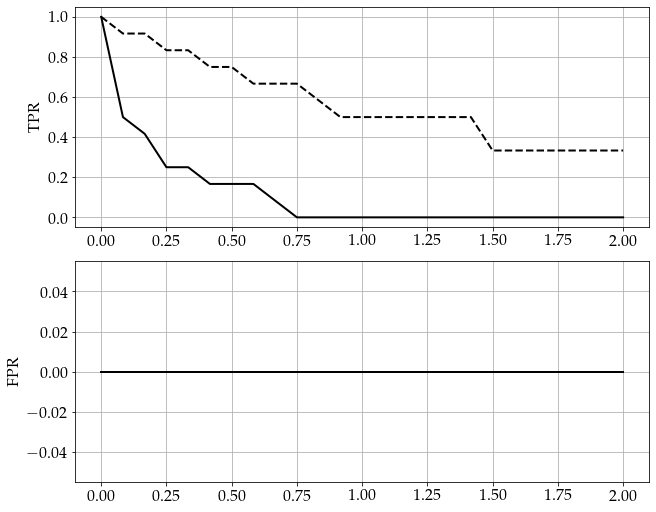

In [7]:
# ROC Curve of the test
tpr_mse = test_statistics.compute_tpr(
    whitebox_test_metadata_df, 'e_mse_true', threshold_true)

fpr_mse = test_statistics.compute_fpr(
    whitebox_test_metadata_df, 'e_mse_true', threshold_true)

test_statistics.plot_tpr_fpr(
    whitebox_test_metadata_df,
    column_names = ['e_mse_true', 'e_male_psi'],
    labels = ['$$MSE$$', '$$MLAE \\Psi$$'],
    styles = ['-', '--'],
    min_threshold=0, max_threshold=2, n_steps=25)

whitebox_test_metadata_df.columns.values

## Blackbox Test the Population of Networks

Here we loop through the population of networks and apply a simulated blackbox test to each pair of original-implemented networks. We track defect statistics over the population.

In [8]:
m_max = 2
threshold_psi = 0.01
threshold_true = 0.01
weight_decay = 0.01
measurement_snr = 0.5
n_fuzz_points = 100
n_epochs = 3
lr = 1e-3
eps = 1e-8

In [9]:
blackbox_test_metadata_df = deepcopy(implemented_metadata_df)

experiment_utils.blackbox_test_population(
    original_networks, implemented_networks,
    blackbox_test_metadata_df,
    alpha_dict, mc_dict, m_max, make_plots=False,
    n_fuzz_points=n_fuzz_points, measurement_snr=measurement_snr,
    n_epochs=n_epochs, weight_decay=weight_decay, lr=lr, eps=eps
)

Processed 1     / 24    in 0.283 s; e_male_psi = 0.02; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 2     / 24    in 0.242 s; e_male_psi = 1.06; e_mse_true = 0.16; e_mse_direct = 0.16;
Processed 3     / 24    in 0.239 s; e_male_psi = 0.00; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 4     / 24    in 0.234 s; e_male_psi = 0.16; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 5     / 24    in 0.263 s; e_male_psi = 0.01; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 6     / 24    in 0.262 s; e_male_psi = 0.96; e_mse_true = 0.57; e_mse_direct = 0.57;
Processed 7     / 24    in 0.266 s; e_male_psi = 0.00; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 8     / 24    in 0.254 s; e_male_psi = 0.29; e_mse_true = 0.40; e_mse_direct = 0.40;
Processed 9     / 24    in 0.305 s; e_male_psi = 0.01; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 10    / 24    in 0.307 s; e_male_psi = 0.16; e_mse_true = 0.02; e_mse_direct = 0.02;
Processed 11    / 24    in 0.263 s; e_male_psi = 0

In [10]:
# Accuracy of the test
print('Direct error accuracy:')
accuracy_asinh_direct_bb = test_statistics.compute_accuracy(
    blackbox_test_metadata_df, 'e_asinh_direct', threshold_true)

accuracy_mse_direct_bb = test_statistics.compute_accuracy(
    blackbox_test_metadata_df, 'e_mse_direct', threshold_true)

accuracy_mae_direct_bb = test_statistics.compute_accuracy(
    blackbox_test_metadata_df, 'e_mae_direct', threshold_true)

accuracy_male_direct_bb = test_statistics.compute_accuracy(
    blackbox_test_metadata_df, 'e_male_direct', threshold_true)

print(
    accuracy_asinh_direct_bb, accuracy_mse_direct_bb,
    accuracy_mae_direct_bb, accuracy_male_direct_bb)

print('Psi accuracy:')
accuracy_asinh_psi_bb = test_statistics.compute_accuracy(
    blackbox_test_metadata_df, 'e_asinh_psi', threshold_psi)

accuracy_mse_psi_bb = test_statistics.compute_accuracy(
    blackbox_test_metadata_df, 'e_mse_psi', threshold_psi)

accuracy_mae_psi_bb = test_statistics.compute_accuracy(
    blackbox_test_metadata_df, 'e_mae_psi', threshold_psi)

accuracy_male_psi_bb = test_statistics.compute_accuracy(
    blackbox_test_metadata_df, 'e_male_psi', threshold_psi)

print(
    accuracy_asinh_psi_bb, accuracy_mse_psi_bb,
    accuracy_mae_psi_bb, accuracy_male_psi_bb)

Direct error accuracy:
0.9166666666666666 0.75 0.9166666666666666 0.5833333333333334
Psi accuracy:
0.9166666666666666 0.5833333333333334 0.7916666666666666 0.7083333333333334


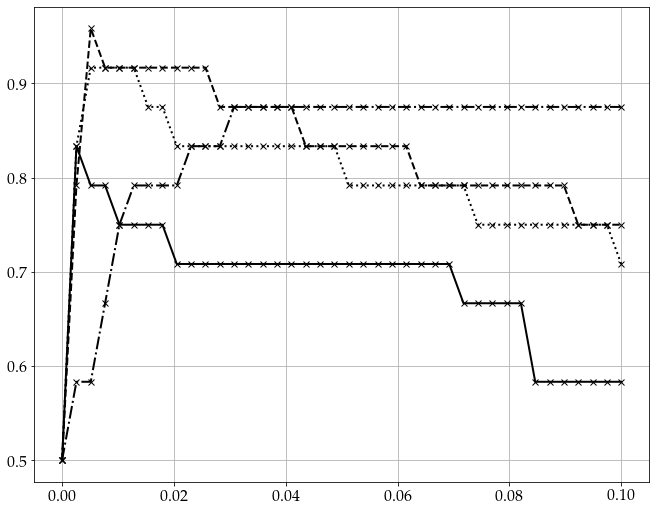

In [11]:
test_statistics.plot_accuracy(
    blackbox_test_metadata_df,
    column_names = [
        'e_mse_direct', 'e_mae_direct',
        'e_asinh_psi', 'e_male_psi'],
    labels = [
        'MSE', 'MAE',
        'asinh Psi', 'male Psi'],
    styles = ['-', '--', ':', '-.'],
    min_threshold=0, max_threshold=0.1, n_steps=40)

array(['activation', 'n_inputs', 'n_hidden', 'true_defect',
       'fit_residual', 'test_snr', 'test_time', 'max_weight_perturbation',
       'avg_weight_perturbation', 'numpy_seed', 'pytorch_seed',
       'e_asinh_psi', 'e_mse_psi', 'e_mae_psi', 'e_male_psi',
       'e_asinh_direct', 'e_mse_direct', 'e_mae_direct', 'e_male_direct',
       'e_asinh_true', 'e_mse_true', 'e_mae_true', 'e_male_true'],
      dtype=object)

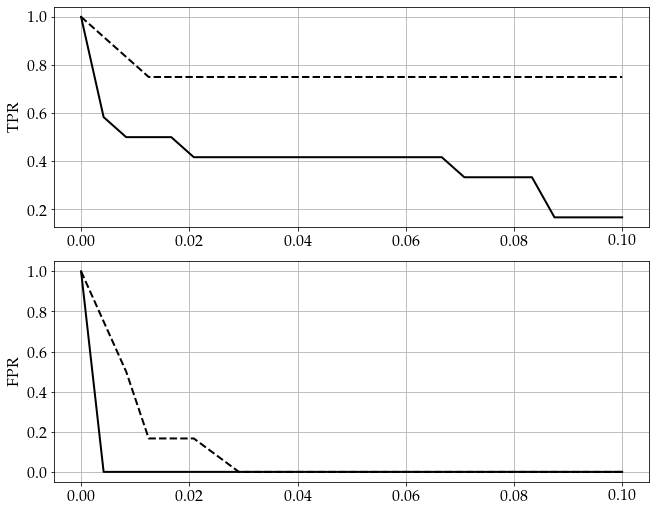

In [12]:
# ROC Curve of the test
test_statistics.plot_tpr_fpr(
    blackbox_test_metadata_df,
    column_names = ['e_mse_direct', 'e_male_psi'],
    labels = ['$$MSE$$', '$$MLAE \\Psi$$'],
    styles = ['-', '--'],
    min_threshold=0, max_threshold=0.1, n_steps=25)

whitebox_test_metadata_df.columns.values

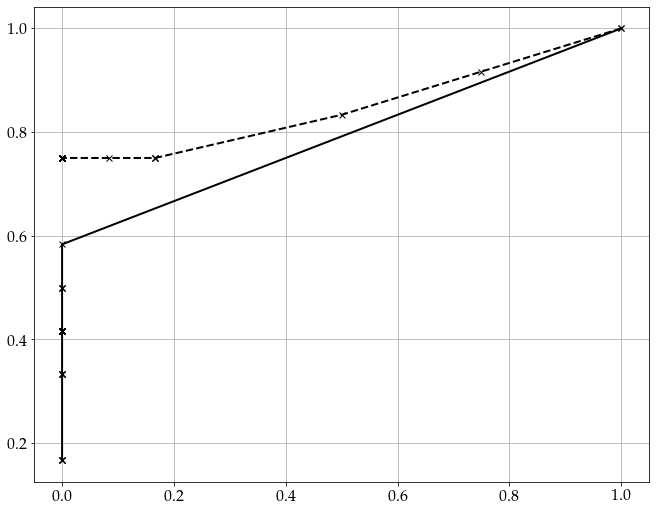

In [13]:
test_statistics.plot_roc(
    blackbox_test_metadata_df,
    column_names = ['e_mse_direct', 'e_male_psi'],
    labels = ['$$MSE$$', '$$MLAE \\Psi$$'],
    styles = ['-', '--'],
    min_threshold=0, max_threshold=0.1, n_steps=25)